Dataset Shape: (10234, 13)
   sleep_hours  sleep_quality  screen_time  study_hours  focus_score  \
0     5.872701              3     7.790856     9.887541     3.099305   
1     8.753572              2     2.310812     1.533934     7.342955   
2     7.659970              1     8.821424     6.006889     7.956352   
3     6.993292              2     6.789919     6.571765     6.125062   
4     4.780093              3     3.064768     4.189529     3.437461   

   exercise_minutes  tasks_completed  procrastination  distractions  \
0         10.327052                8         8.782302             2   
1         25.369378                8         2.408089             5   
2         44.429386                7         2.108028             0   
3         31.958194                2         1.873712             1   
4         40.899447                2         1.667393             9   

   break_time      mood  stress_level  productive  
0  176.811540  8.120997      4.950414           1  
1   91.25

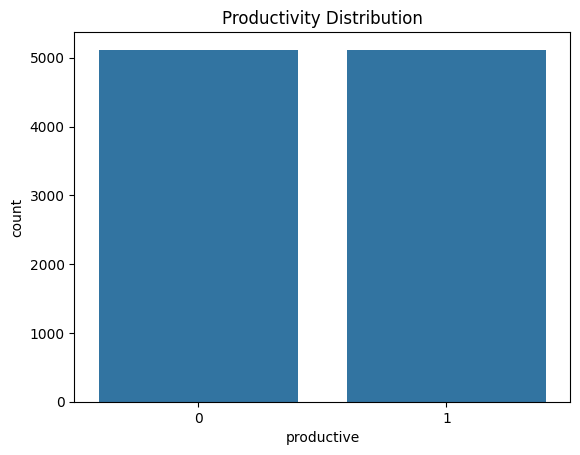

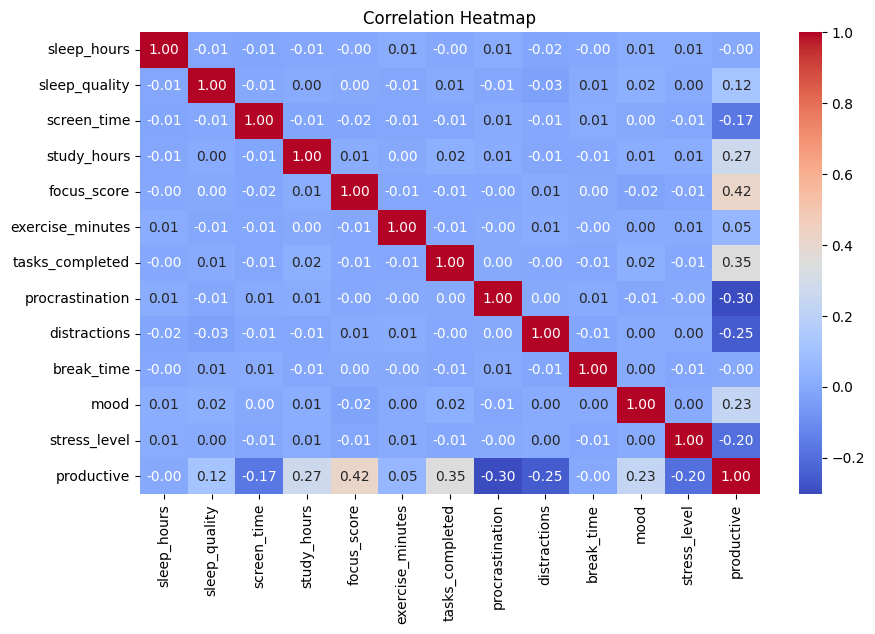


Cross Validation Score: 0.9231973357286561

Accuracy: 0.9301416707376648

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      1056
           1       0.93      0.93      0.93       991

    accuracy                           0.93      2047
   macro avg       0.93      0.93      0.93      2047
weighted avg       0.93      0.93      0.93      2047



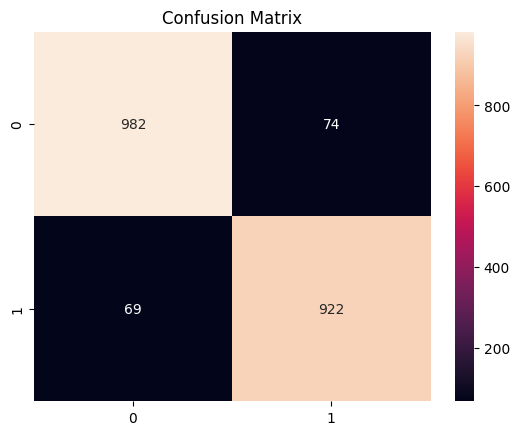

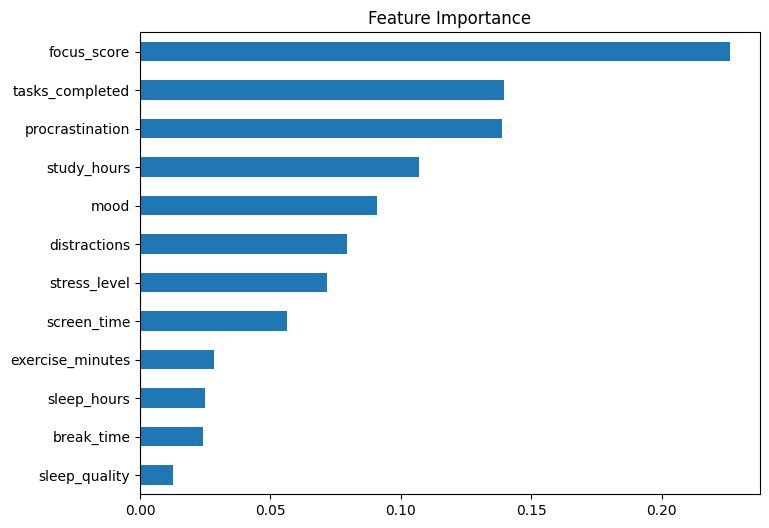


Top Features:
 focus_score         0.226407
tasks_completed     0.139715
procrastination     0.138928
study_hours         0.107011
mood                0.090772
distractions        0.079256
stress_level        0.071606
screen_time         0.056364
exercise_minutes    0.028488
sleep_hours         0.024814
break_time          0.024139
sleep_quality       0.012499
dtype: float64

Most Important Feature: focus_score


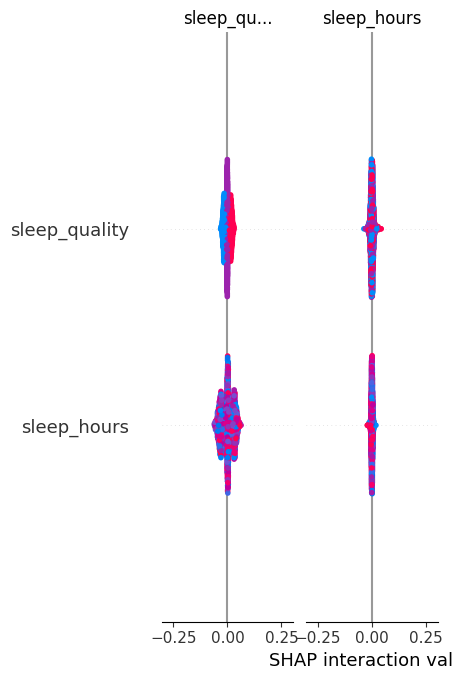

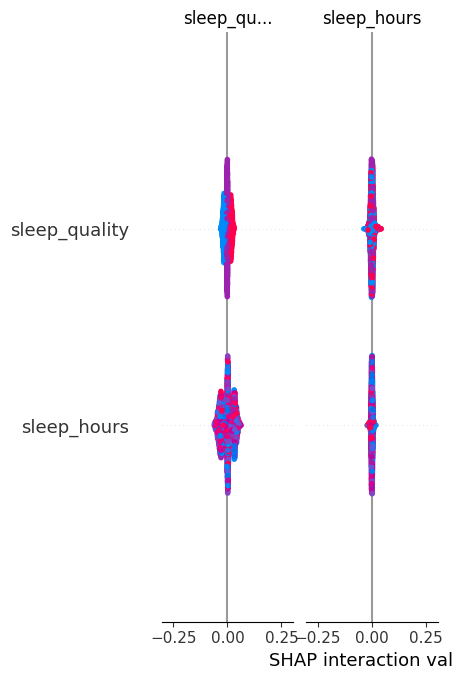


📊 RESULT:
Productive ✅
Confidence: 51.56 %

🧠 Suggestions:
- ⚠️ Low physical activity
✅ Model saved successfully!


In [5]:
# ===============================
# 1. Import Libraries
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

# ===============================
# 2. Load Dataset
# ===============================
data = pd.read_csv("final_productivity_dataset_10k (1).csv")

print("Dataset Shape:", data.shape)
print(data.head())

# ===============================
# 3. Data Visualization
# ===============================
plt.figure()
sns.countplot(x=data["productive"])
plt.title("Productivity Distribution")
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(data.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# ===============================
# 4. Define Features & Target
# ===============================
X = data.drop(["productive"], axis=1)
y = data["productive"]

# ===============================
# 5. Train-Test Split
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===============================
# 6. Train Model
# ===============================
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

# ===============================
# 7. Cross Validation (NEW 🔥)
# ===============================
cv_score = cross_val_score(rf, X, y, cv=5).mean()
print("\nCross Validation Score:", cv_score)

# ===============================
# 8. Prediction
# ===============================
y_pred = rf.predict(X_test)

# ===============================
# 9. Evaluation
# ===============================
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ===============================
# 10. Confusion Matrix
# ===============================
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()

# ===============================
# 11. Feature Importance
# ===============================
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance = importance.sort_values()

plt.figure(figsize=(8,6))
importance.plot(kind="barh")
plt.title("Feature Importance")
plt.show()

print("\nTop Features:\n", importance.sort_values(ascending=False))
print("\nMost Important Feature:", importance.idxmax())

# ===============================
# ===============================
# 12. SHAP (FINAL FIXED VERSION)
# ===============================
import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

# 🔥 Handle both cases safely
if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1]   # binary classification
else:
    shap_values_to_plot = shap_values

# Ensure shape match
shap_values_to_plot = np.array(shap_values_to_plot)

# Plot
shap.summary_plot(shap_values_to_plot, X_test)
shap.summary_plot(shap_values_to_plot, X_test, plot_type="bar")

# ===============================
# 13. Insights Engine
# ===============================
def generate_insights(data):
    insights = []

    if data["sleep_hours"] < 6:
        insights.append("⚠️ Low sleep")

    if data["screen_time"] > data["study_hours"]:
        insights.append("⚠️ Too much screen time")

    if data["focus_score"] < 5:
        insights.append("⚠️ Improve focus")

    if data["exercise_minutes"] < 20:
        insights.append("⚠️ Low physical activity")

    if data["procrastination"] > 6:
        insights.append("⚠️ High procrastination")

    if data["stress_level"] > 7:
        insights.append("⚠️ High stress")

    return insights

# ===============================
# 14. User Input
# ===============================
def get_user_input():
    return {
        "sleep_hours": float(input("Sleep hours: ")),
        "sleep_quality": int(input("Sleep quality (1-3): ")),
        "screen_time": float(input("Screen time: ")),
        "study_hours": float(input("Study hours: ")),
        "focus_score": float(input("Focus score: ")),
        "exercise_minutes": float(input("Exercise minutes: ")),
        "tasks_completed": int(input("Tasks completed: ")),
        "procrastination": float(input("Procrastination: ")),
        "distractions": int(input("Distractions: ")),
        "break_time": float(input("Break time: ")),
        "mood": float(input("Mood: ")),
        "stress_level": float(input("Stress level: "))
    }

# ===============================
# 15. Prediction
# ===============================
user_input = get_user_input()

input_df = pd.DataFrame([user_input])
input_df = input_df[X.columns]

prediction = rf.predict(input_df)[0]
prob = rf.predict_proba(input_df)[0][1]

print("\n📊 RESULT:")
print("Productive ✅" if prediction == 1 else "Not Productive ❌")
print("Confidence:", round(prob * 100, 2), "%")

# ===============================
# 16. Insights
# ===============================
print("\n🧠 Suggestions:")

insights = generate_insights(user_input)

if len(insights) == 0:
    print("✅ Excellent habits!")
else:
    for i in insights:
        print("-", i)

# ===============================
# 17. Save Model
# ===============================
joblib.dump(rf, "productivity_model.pkl")
joblib.dump(X.columns.tolist(), "feature_order.pkl")

print("✅ Model saved successfully!")